In [1]:
import numpy as np
import matplotlib.pyplot as plt
from grid_cells.random_walk import generate_bat_flight
from grid_cells.attractor_networks import HeadDirection, BatHeadDirectionSystem
from grid_cells.plot_tools import angular_error
import os
import tqdm

DATA_DIR = "../simulation_data"
PLOTS_DIR = "../plots"

In [2]:
## Simulation parameters:
n_min_plots = 10
T = 400
dt = 0.5e-3
n = 256
net = BatHeadDirectionSystem(input_noise=1, intrinsic_noise=0.005)
net.warm_up()
bat_flight = generate_bat_flight(T=T, dt=dt)
n_steps = bat_flight["pos"].shape[0]

recording = net.run_simulation(
    bat_flight["dir_vel"]
)  # , dir = bat_flight["dir_torus"])

Ran warm up for 132 steps


Running Simulation Steps: 100%|██████████| 800000/800000 [02:19<00:00, 5722.61it/s]


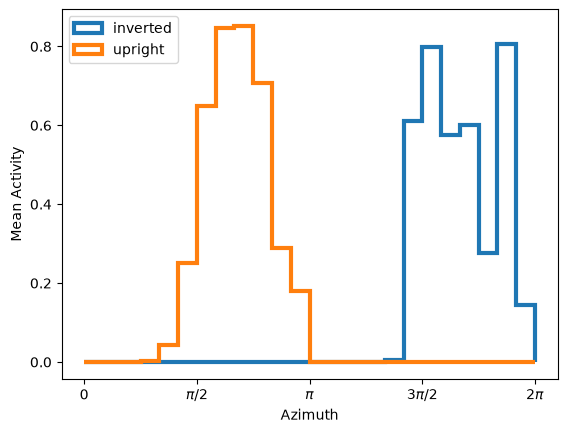

In [3]:
from grid_cells.plot_tools import activity_map

cell_index = 0
inverted = bat_flight["inverted"]
azimuth = bat_flight["dir_sphere"][:, 0] + np.pi
bins = np.linspace(0, 2 * np.pi, 25)

cell_recording = recording["azimuth_cells"][:, cell_index]
fig, ax = plt.subplots()  # subplot_kw={'projection': 'polar'}, layout='constrained')
plt.hist(
    azimuth[inverted],
    weights=cell_recording[inverted],
    bins=bins,
    label="inverted",
    density=True,
    histtype="step",
    linewidth=3,
)
plt.hist(
    azimuth[~inverted],
    weights=cell_recording[~inverted],
    bins=bins,
    label="upright",
    density=True,
    histtype="step",
    linewidth=3,
)
ax.set_xlabel("Azimuth")
ax.set_ylabel("Mean Activity")

ax.set_xticks(np.arange(0, 2.5, 0.5) * np.pi)
ax.set_xticklabels([r"0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"2$\pi$"])
ax.legend(loc="best")
fig.savefig(os.path.join(PLOTS_DIR, "bat_flight_inverted_pure_cell.png"))

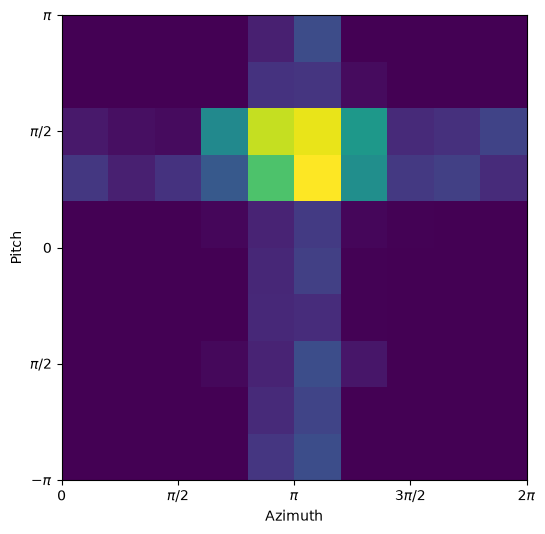

In [4]:
from grid_cells.plot_tools import activity_map

cell_index = 3
direction_activity_map, counts, direction_edges = activity_map(
    bat_flight["dir_torus"], recording["conj_cells"][:, cell_index], nbins=10
)
fig, ax = plt.subplots(figsize=(6, 10))
ax.imshow(
    direction_activity_map.T,
    extent=(
        direction_edges[0][0] / np.pi,
        direction_edges[0][-1] / np.pi,
        direction_edges[1][0] / np.pi,
        direction_edges[1][-1] / np.pi,
    ),
    # interpolation="bilinear",
    origin="lower",
)
ax.set_xlabel("Azimuth")
ax.set_xticks(np.arange(0, 2.5, 0.5))
ax.set_xticklabels([r"0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"2$\pi$"])

ax.set_ylabel("Pitch")
ax.set_yticks(np.arange(-1, 1.5, 0.5))
ax.set_yticklabels([r"$-\pi$", r"$\pi/2$", r"0", r"$\pi/2$", r"$\pi$"])

fig.savefig(os.path.join(PLOTS_DIR, "bat_flight_3d_direction_grid_aperiodic.png"))

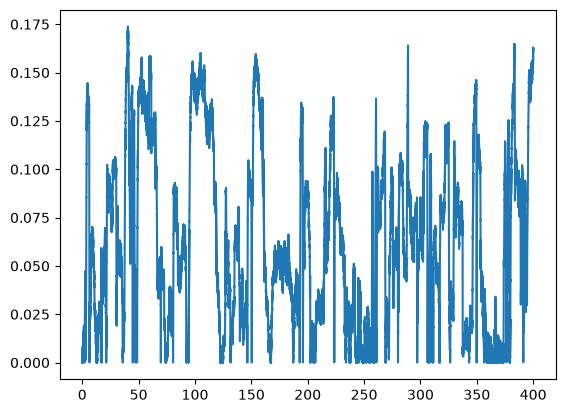

In [8]:
plt.plot(
    bat_flight["time"],
    np.abs(angular_error(recording["decoded_azimuth"], bat_flight["dir_torus"][:, 0])),
)

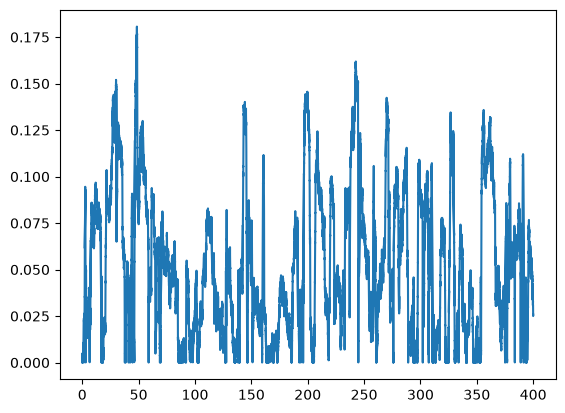

In [6]:
plt.plot(
    bat_flight["time"],
    np.abs(angular_error(recording["decoded_pitch"], bat_flight["dir_torus"][:, 1])),
)